In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

from scipy.interpolate import InterpolatedUnivariateSpline as IUS

In [2]:
# for now grab from quickrun file
p = 10.0
e = 0.2
a = 0.5

n_radial = 40
n_theta = 40

In [3]:
r_min = p / (1.0 + e)
r_max = p / (1.0 - e)

r_mean = (r_min + r_max) / 2.0

r_min_field = r_min - 1.0
r_max_field = r_max + 1.0

theta_min = np.pi/2 - 0.08
theta_max = np.pi/2 + 0.08

delta_r = (r_max_field - r_min_field) / (n_radial - 1.0)
delta_theta = (theta_max - theta_min) / (n_theta - 1.0)

r_vals = np.zeros(n_radial)
th_vals = np.zeros(n_theta)

for i in range(n_radial):
    r_vals[i] = r_min_field + i*delta_r

for i in range(n_theta):
    th_vals[i] = theta_min + i*delta_theta

close = (np.argmin(np.abs(r_vals - r_mean)), np.argmin(np.abs(th_vals - np.pi/2)))

In [4]:
def data_loader(filename_re, filename_im, n_radial, n_theta):

    full_data_re = np.genfromtxt(filename_re, delimiter=",")
    full_data_im = np.genfromtxt(filename_im, delimiter=",")

    field_data_slices = []
    for i, t in enumerate(full_data_re[:, 0]):
        field_data_slices.append(
            [
                t,
                full_data_re[i, 1:].reshape(n_theta, n_radial)
                + 1j * full_data_im[i, 1:].reshape(n_theta, n_radial),
            ]
        )

    timeseries_dict = {
        (j, i): {
            "time": full_data_re[:, 0],
            "data": (full_data_re[:, 1:].T[i * n_radial + j]
            + 1j * full_data_im[:, 1:].T[i * n_radial + j]),
            "field": (r_vals[j], th_vals[i]),
        }
        for i in range(len(th_vals))
        for j in range(len(r_vals))
    }

    return field_data_slices, timeseries_dict

## Trajectory

In [12]:
# load data
traj_data_path = "../data/trajectory.dat"
lam, t, r_p, phi_p, ur = np.loadtxt(traj_data_path).T

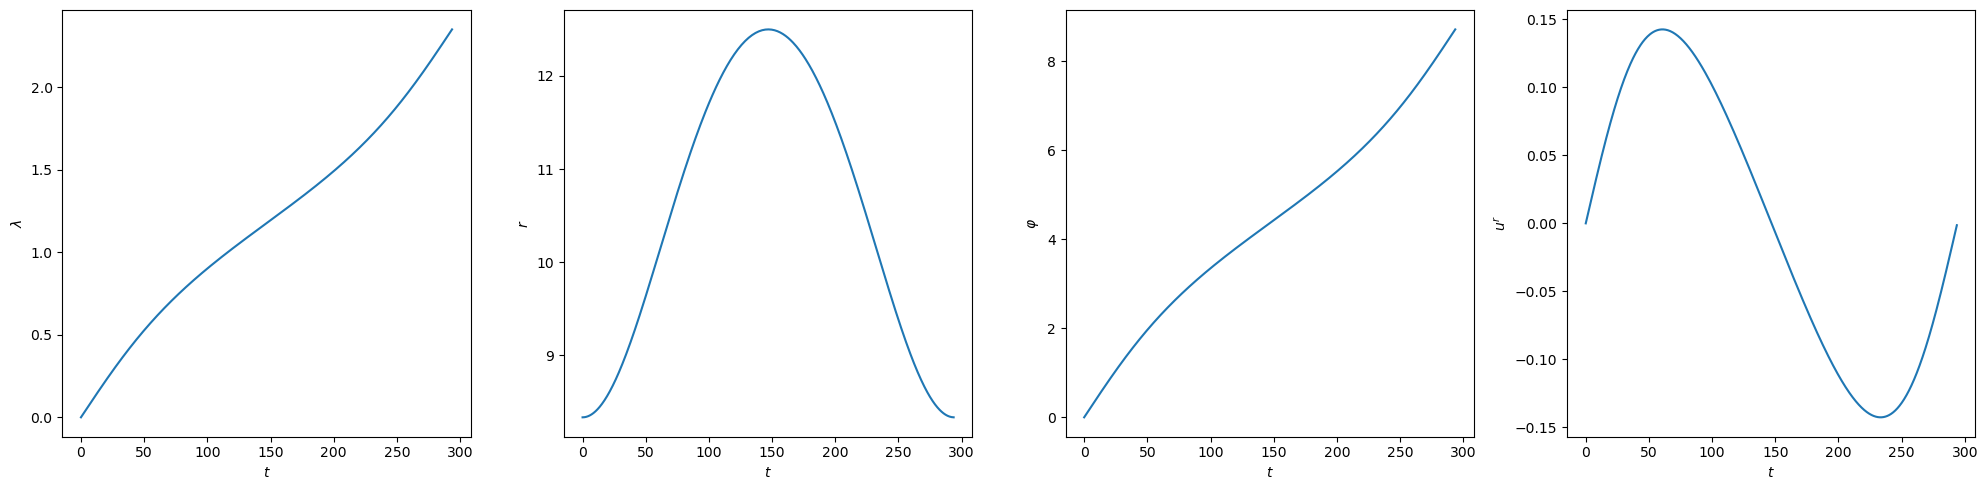

In [13]:
fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(20,5))
axs[0].plot(t,lam)
axs[0].set_ylabel(r'$\lambda$')
axs[1].plot(t,r_p)
axs[1].set_ylabel(r'$r$')
axs[2].plot(t,phi_p)
axs[2].set_ylabel(r'$\varphi$')
axs[3].plot(t,ur)
axs[3].set_ylabel(r'$u^r$')

for ax in axs:
    ax.set_xlabel(r'$t$')

plt.tight_layout()
plt.show()

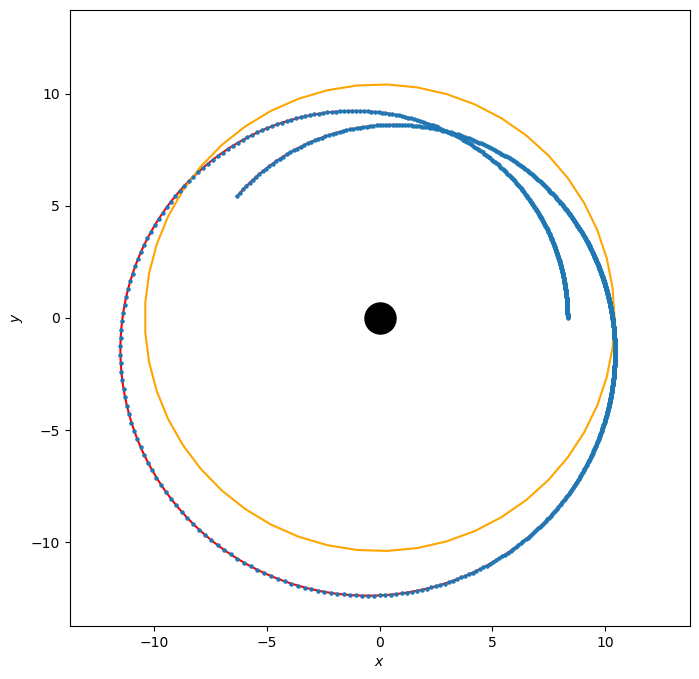

In [14]:
plt.figure(figsize=(8,8))
rmax = np.max(r_p)*1.1
plt.plot(r_p*np.cos(phi_p), r_p*np.sin(phi_p),c='r')
plt.scatter(r_p*np.cos(phi_p), r_p*np.sin(phi_p), s=5,zorder=10)
plt.scatter(0,0, s=500, c='k')

plot_thetas = np.linspace(0,2*np.pi)
plt.plot(r_mean*np.cos(plot_thetas), r_mean*np.sin(plot_thetas), c='orange')

plt.xlim(-rmax, rmax)
plt.ylim(-rmax, rmax)
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.show()

# Timeseries Field

In [15]:
field_data_slices, field_timeseries_dict = data_loader("../data/puncture_re.dat","../data/puncture_im.dat",n_radial, n_theta)

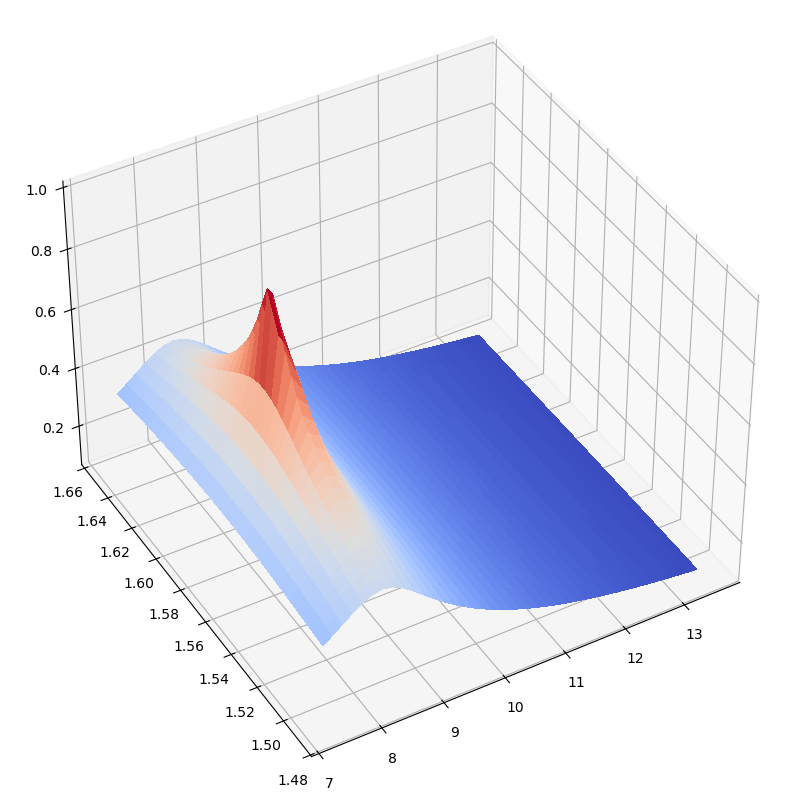

In [16]:
X, Y = np.meshgrid(r_vals, th_vals)
dat = np.array(field_data_slices[0][1])

fig, ax = plt.subplots(figsize=(10,10), subplot_kw={"projection":"3d"})
ax.view_init(elev=40, azim=-120, roll=0)

ax.plot_surface(X, Y, np.abs(dat), cmap=cm.coolwarm, linewidth=0, antialiased=False)
plt.show()

In [72]:
# import matplotlib.animation as animation
# X, Y = np.meshgrid(r_vals, th_vals)

# fig, ax = plt.subplots(figsize=(10,10), subplot_kw={"projection":"3d"})
# ax.view_init(elev=40, azim=-120, roll=0)

# ims = []
# for i in range(len(field_data_slices)):
#     dat = np.array(field_data_slices[i][1])

#     im = ax.plot_surface(X, Y, np.abs(dat), cmap=cm.coolwarm, linewidth=0, antialiased=False)
#     ims.append([im])

# ani = animation.ArtistAnimation(fig, ims, interval=50, blit=True, repeat_delay=1000)

# ani.save("field.mp4")

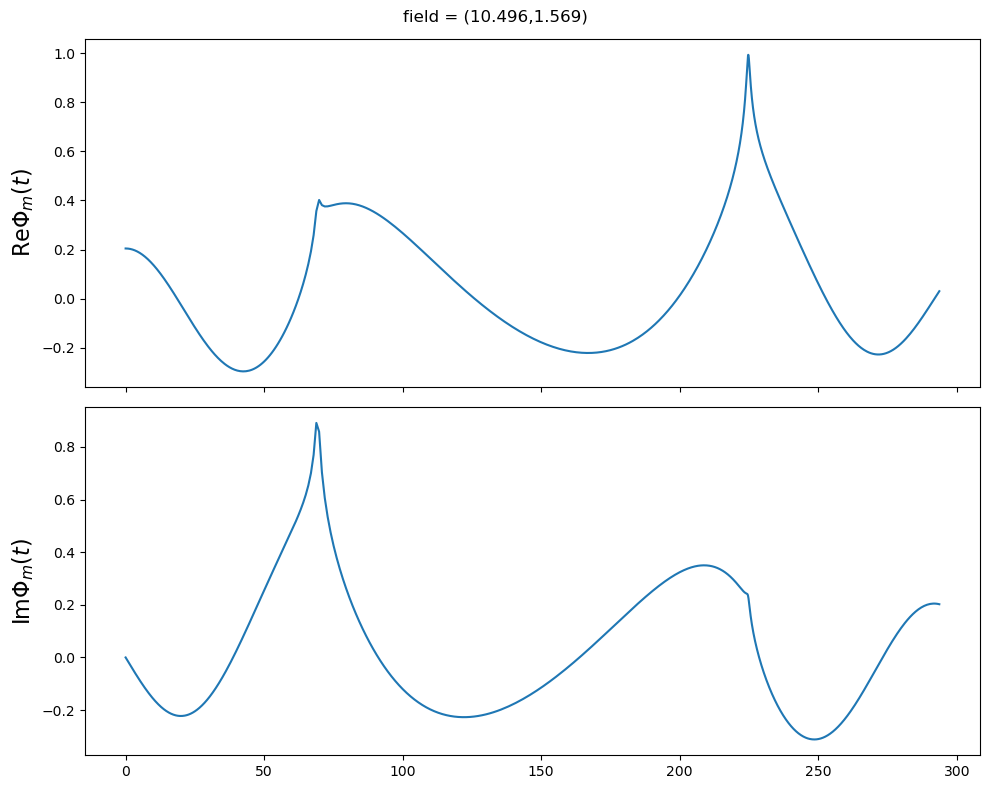

In [17]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(10,8), sharex=True)

data_dict = field_timeseries_dict

pt = close
fr, ft = data_dict[pt]['field']

axs[0].plot(data_dict[pt]["time"],data_dict[pt]["data"].real)
axs[0].set_ylabel(r'Re$\Phi_m(t)$',fontsize=16)
axs[1].plot(data_dict[pt]["time"],data_dict[pt]["data"].imag)
axs[1].set_ylabel(r'Im$\Phi_m(t)$',fontsize=16)

plt.suptitle(f"field = ({fr:0.3f},{ft:0.3f})")
plt.tight_layout()
plt.show()

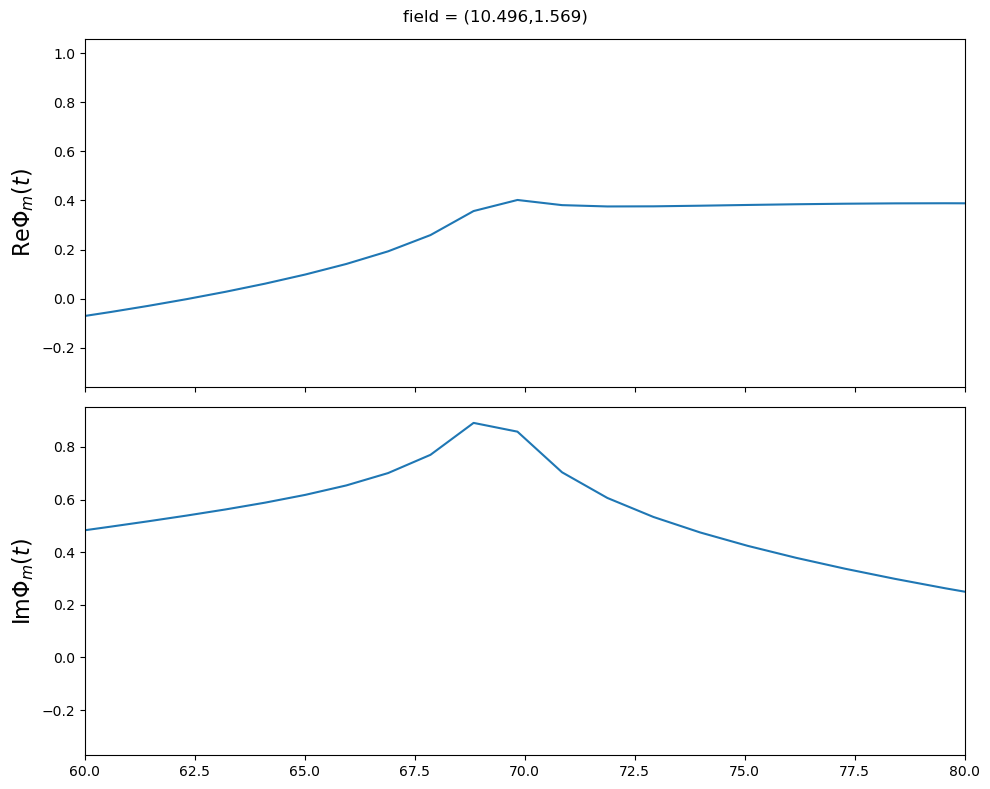

In [18]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(10,8), sharex=True)

data_dict = field_timeseries_dict

pt = close
fr, ft = data_dict[pt]['field']

axs[0].plot(data_dict[pt]["time"],data_dict[pt]["data"].real)
axs[0].set_ylabel(r'Re$\Phi_m(t)$',fontsize=16)
axs[1].plot(data_dict[pt]["time"],data_dict[pt]["data"].imag)
axs[1].set_ylabel(r'Im$\Phi_m(t)$',fontsize=16)

axs[1].set_xlim(60,80)

plt.suptitle(f"field = ({fr:0.3f},{ft:0.3f})")
plt.tight_layout()
plt.show()

In [19]:
field_rad = r_vals[close[0]]
field_inc = th_vals[close[1]]
dist = np.sqrt(r_p**2+field_rad**2-2*r_p*field_rad*np.sin(field_inc)*np.cos(phi_p))/r_mean
dist_int = IUS(t, dist)

In [20]:
dt = 1
t_set = 0
t_list = []

while t_set < t[-1]:
    t_list.append(t_set)
    t_set += dt * dist_int(t_set)

In [21]:
t_test, field_test = field_timeseries_dict[pt]["time"], field_timeseries_dict[pt]["data"].real
field_int = IUS(t_test, field_test)

(224.0, 226.0)

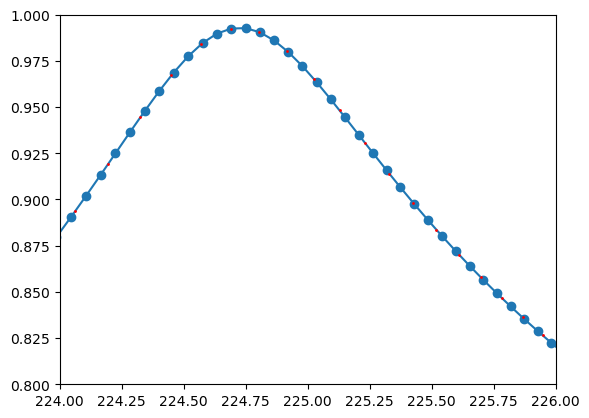

In [22]:
plt.plot(t_test, field_test)
plt.scatter(t_test,field_test)
# plt.plot(t_test, field_int(t_test))
plt.scatter(t_list, field_int(t_list),s=1,c='r',zorder=5)
plt.ylim(0.8,1)
plt.xlim(224,226)

(150.0, 152.0)

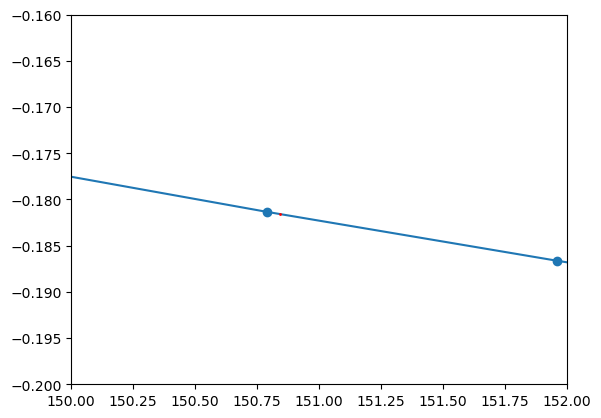

In [23]:
plt.plot(t_test, field_test)
plt.scatter(t_test,field_test)
# plt.plot(t_test, field_int(t_test))
plt.scatter(t_list, field_int(t_list),s=1,c='r',zorder=5)
plt.ylim(-0.2,-0.16)
plt.xlim(150,152)

# Source

In [58]:
src_data_slices, src_timeseries_dict = data_loader("../data/source_re.dat","../data/source_im.dat",n_radial, n_theta)

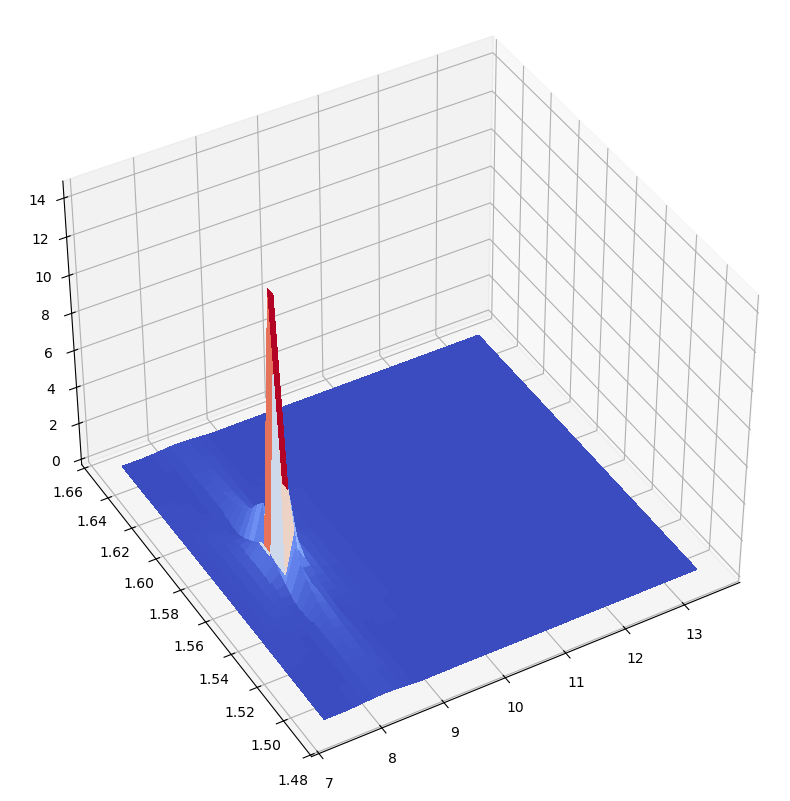

In [59]:
X, Y = np.meshgrid(r_vals, th_vals)
dat = np.array(src_data_slices[0][1])

fig, ax = plt.subplots(figsize=(10,10), subplot_kw={"projection":"3d"})
ax.view_init(elev=40, azim=-120, roll=0)

ax.plot_surface(X, Y, np.abs(dat), cmap=cm.coolwarm, linewidth=0, antialiased=False)
plt.show()

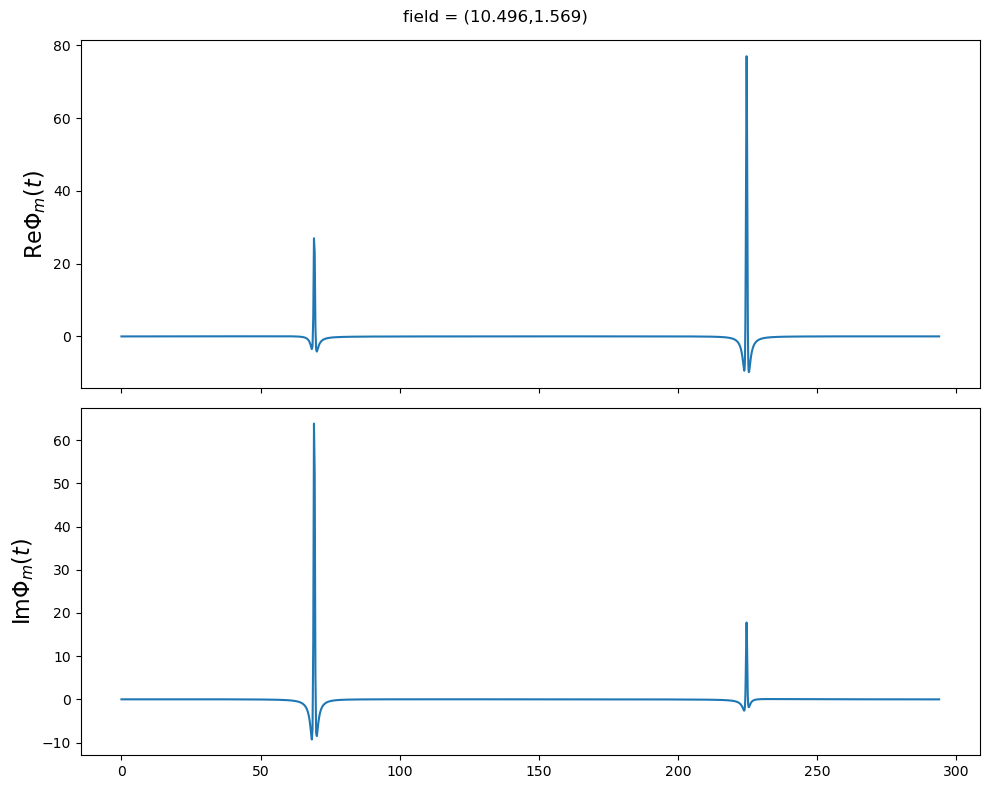

In [60]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(10,8), sharex=True)

data_dict = src_timeseries_dict

pt = close
fr, ft = data_dict[pt]['field']

axs[0].plot(data_dict[pt]["time"],data_dict[pt]["data"].real)
axs[0].set_ylabel(r'Re$\Phi_m(t)$',fontsize=16)
axs[1].plot(data_dict[pt]["time"],data_dict[pt]["data"].imag)
axs[1].set_ylabel(r'Im$\Phi_m(t)$',fontsize=16)

plt.suptitle(f"field = ({fr:0.3f},{ft:0.3f})")
plt.tight_layout()
plt.show()

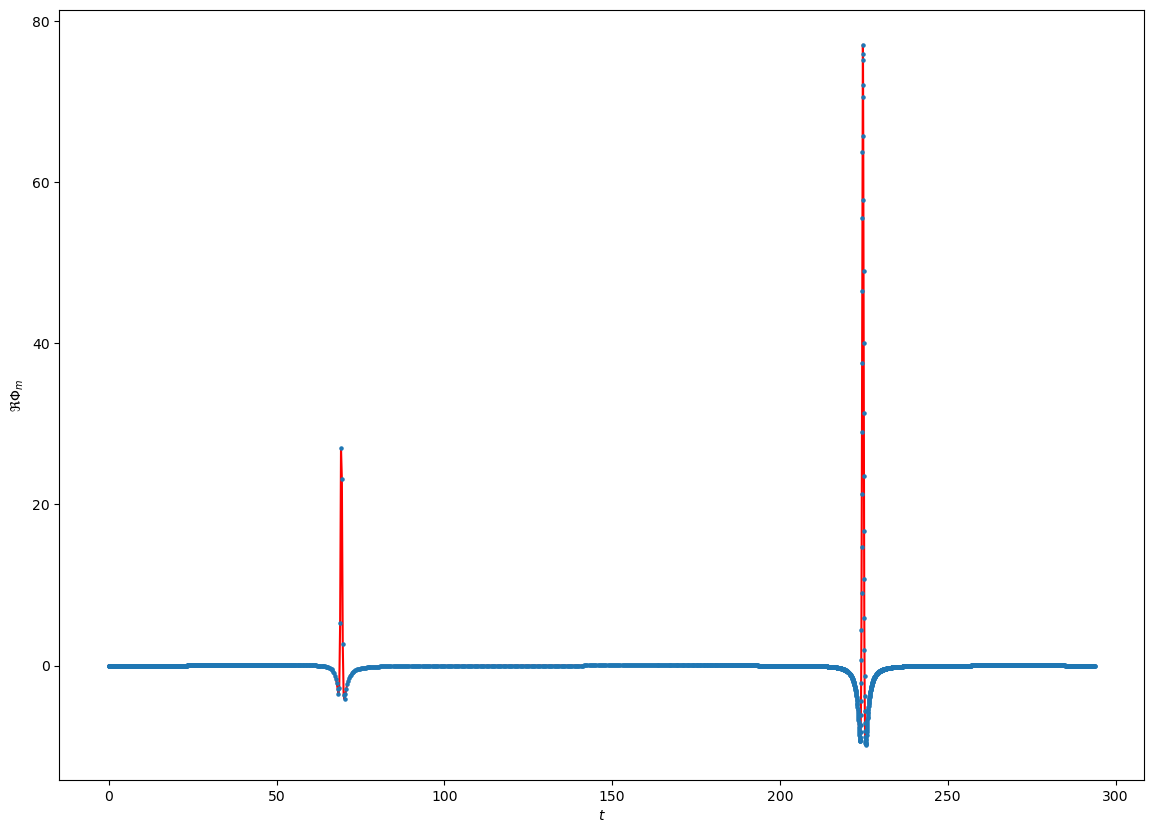

In [61]:
fig = plt.figure(figsize=(14,10))
plt.plot(data_dict[pt]["time"],data_dict[pt]["data"].real, c='r')
plt.scatter(data_dict[pt]["time"],data_dict[pt]["data"].real, s=5, zorder=10)
plt.ylabel(r'$\Re\Phi_m$')
plt.xlabel(r'$t$')
plt.show()

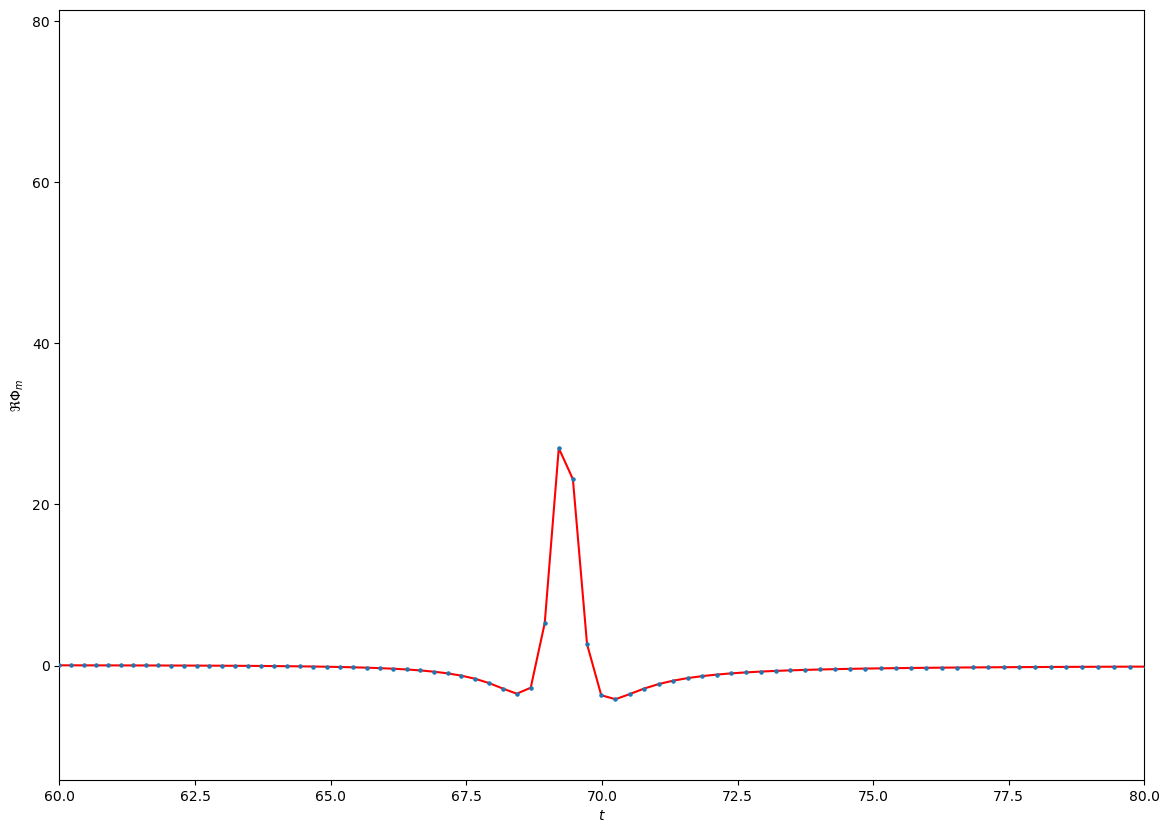

In [62]:
fig = plt.figure(figsize=(14,10))
plt.plot(data_dict[pt]["time"],data_dict[pt]["data"].real, c='r')
plt.scatter(data_dict[pt]["time"],data_dict[pt]["data"].real, s=5, zorder=10)
plt.xlim(60,80)
plt.ylabel(r'$\Re\Phi_m$')
plt.xlabel(r'$t$')
plt.show()

## Derivatives

### dr

In [19]:
dr_field_data_slices, dr_field_timeseries_dict = data_loader("../data/puncture_dr_re.dat","../data/puncture_dr_im.dat",n_radial, n_theta)

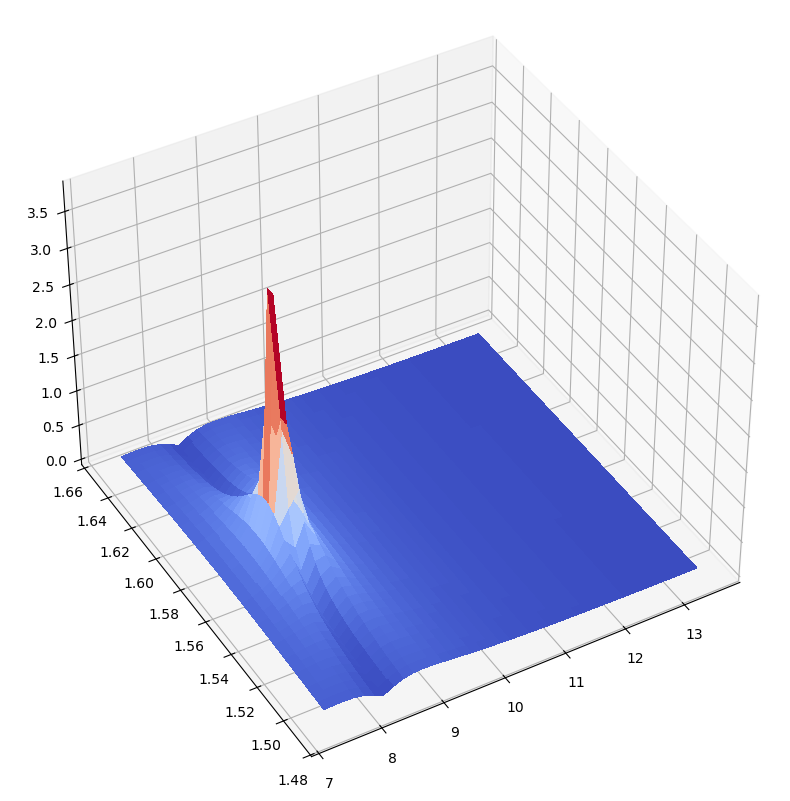

In [20]:
X, Y = np.meshgrid(r_vals, th_vals)
dat = np.array(dr_field_data_slices[0][1])

fig, ax = plt.subplots(figsize=(10,10), subplot_kw={"projection":"3d"})
ax.view_init(elev=40, azim=-120, roll=0)

ax.plot_surface(X, Y, np.abs(dat), cmap=cm.coolwarm, linewidth=0, antialiased=False)
plt.show()

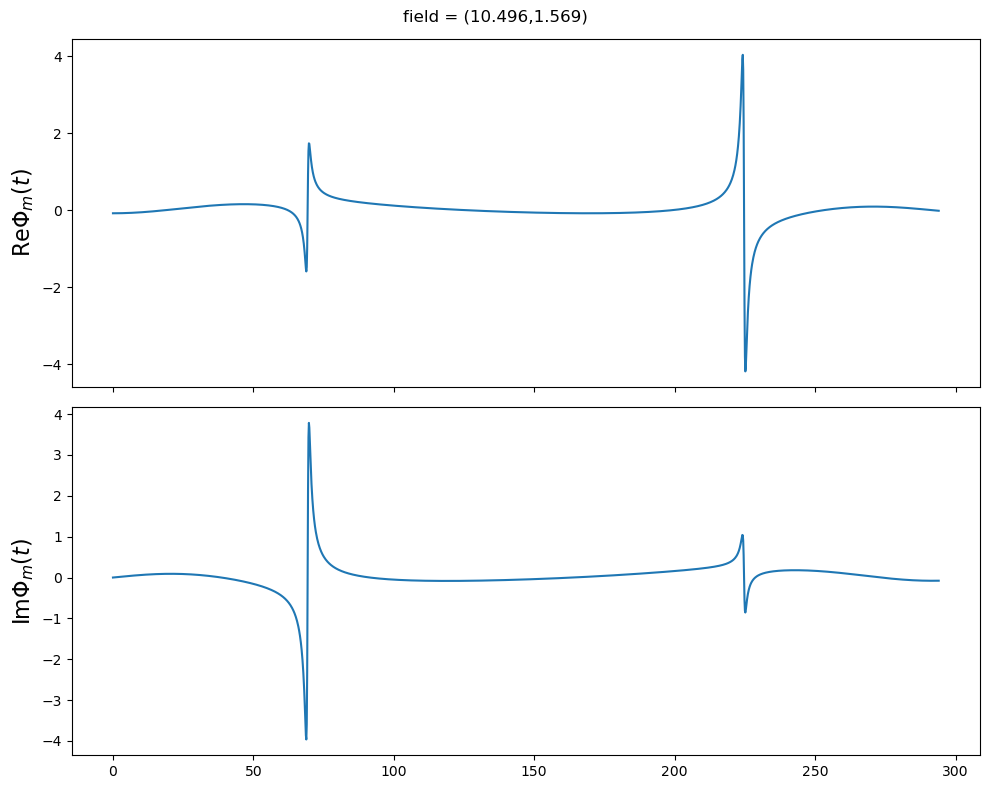

In [21]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(10,8), sharex=True)

data_dict = dr_field_timeseries_dict

pt = close
fr, ft = data_dict[pt]['field']

axs[0].plot(data_dict[pt]["time"],data_dict[pt]["data"].real)
axs[0].set_ylabel(r'Re$\Phi_m(t)$',fontsize=16)
axs[1].plot(data_dict[pt]["time"],data_dict[pt]["data"].imag)
axs[1].set_ylabel(r'Im$\Phi_m(t)$',fontsize=16)

plt.suptitle(f"field = ({fr:0.3f},{ft:0.3f})")
plt.tight_layout()
plt.show()

### dtheta

In [22]:
dth_field_data_slices, dth_field_timeseries_dict = data_loader("../data/puncture_dth_re.dat","../data/puncture_dth_im.dat",n_radial, n_theta)

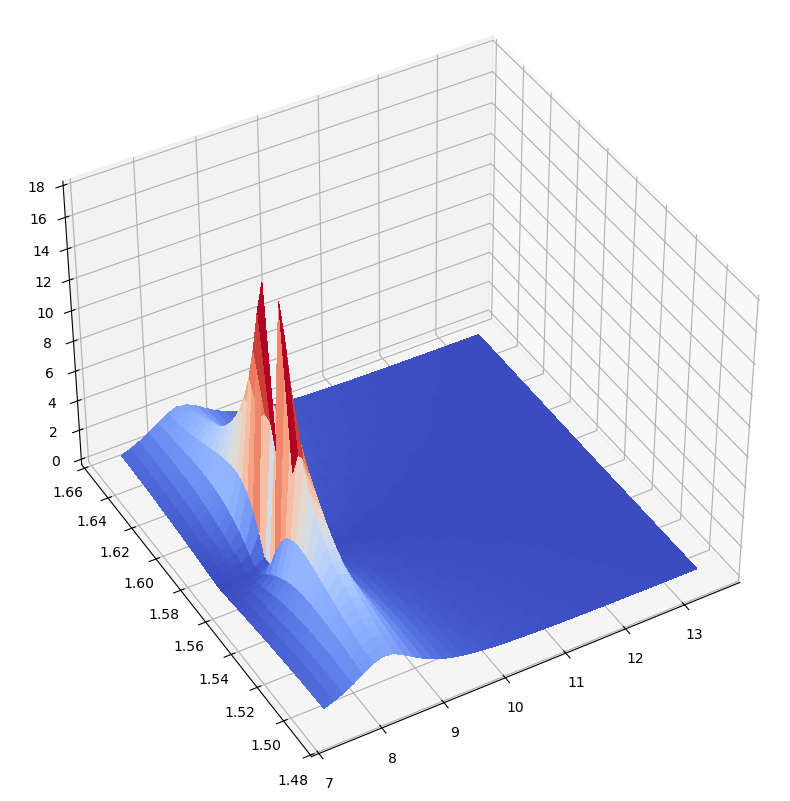

In [23]:
X, Y = np.meshgrid(r_vals, th_vals)
dat = np.array(dth_field_data_slices[0][1])

fig, ax = plt.subplots(figsize=(10,10), subplot_kw={"projection":"3d"})
ax.view_init(elev=40, azim=-120, roll=0)

ax.plot_surface(X, Y, np.abs(dat), cmap=cm.coolwarm, linewidth=0, antialiased=False)
plt.show()

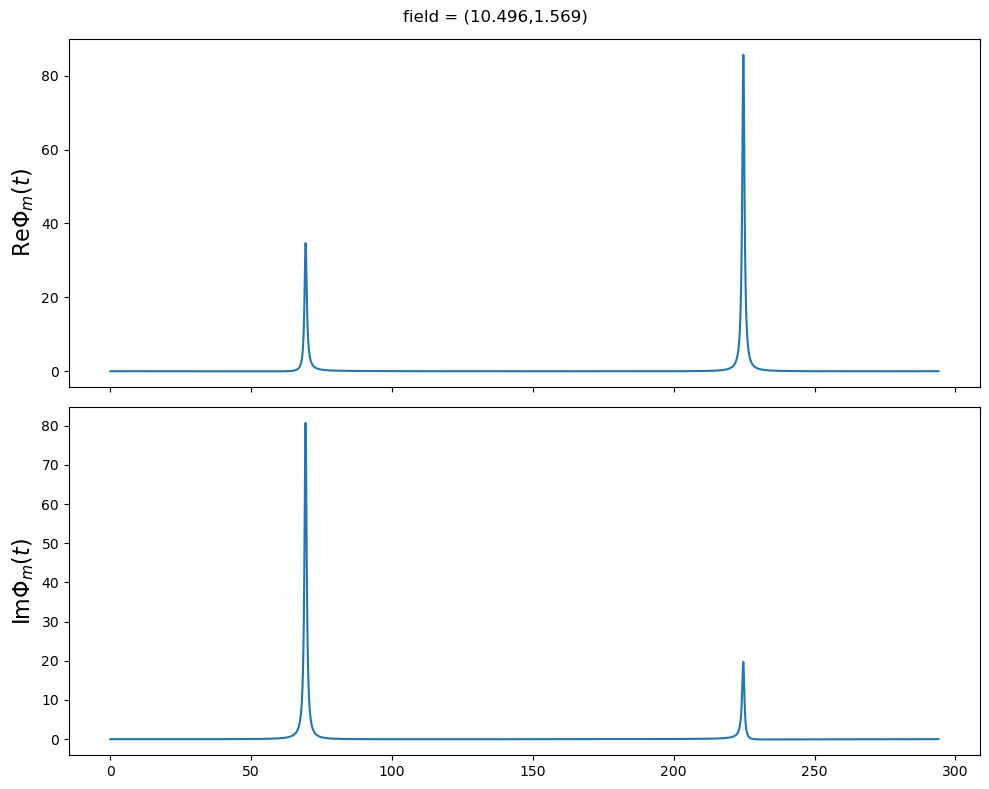

In [24]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(10,8), sharex=True)

data_dict = dth_field_timeseries_dict

pt = close
fr, ft = data_dict[pt]['field']

axs[0].plot(data_dict[pt]["time"],data_dict[pt]["data"].real)
axs[0].set_ylabel(r'Re$\Phi_m(t)$',fontsize=16)
axs[1].plot(data_dict[pt]["time"],data_dict[pt]["data"].imag)
axs[1].set_ylabel(r'Im$\Phi_m(t)$',fontsize=16)

plt.suptitle(f"field = ({fr:0.3f},{ft:0.3f})")
plt.tight_layout()
plt.show()

# n-mode data

In [25]:
n_field_data_slices, n_field_timeseries_dict = data_loader("../data/n_puncture_re.dat","../data/n_puncture_im.dat",n_radial, n_theta)

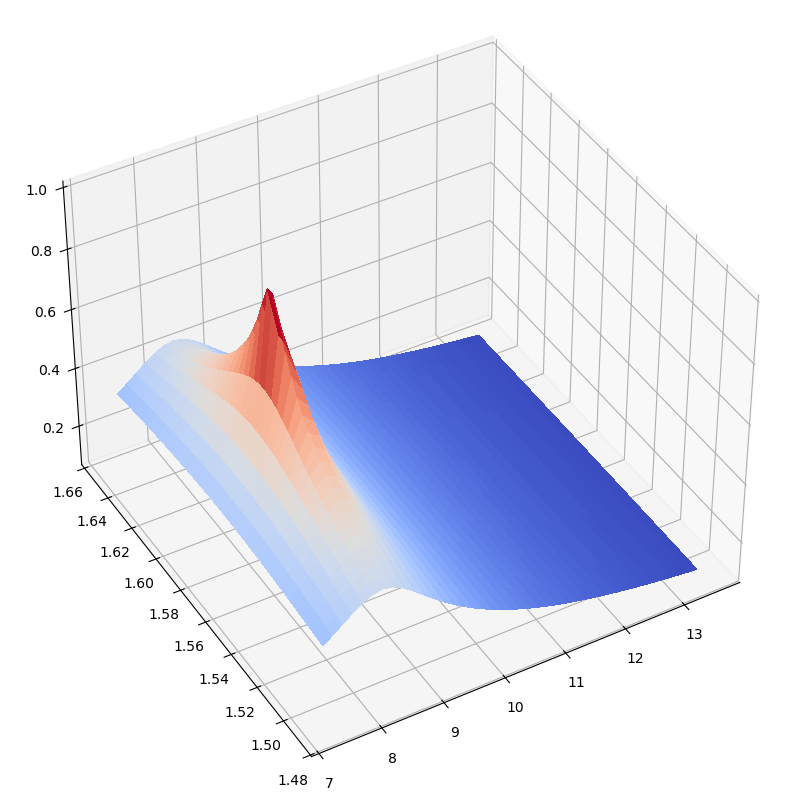

In [26]:
X, Y = np.meshgrid(r_vals, th_vals)
dat = np.array(n_field_data_slices[0][1])

fig, ax = plt.subplots(figsize=(10,10), subplot_kw={"projection":"3d"})
ax.view_init(elev=40, azim=-120, roll=0)

ax.plot_surface(X, Y, np.real(dat), cmap=cm.coolwarm, linewidth=0, antialiased=False)
plt.show()

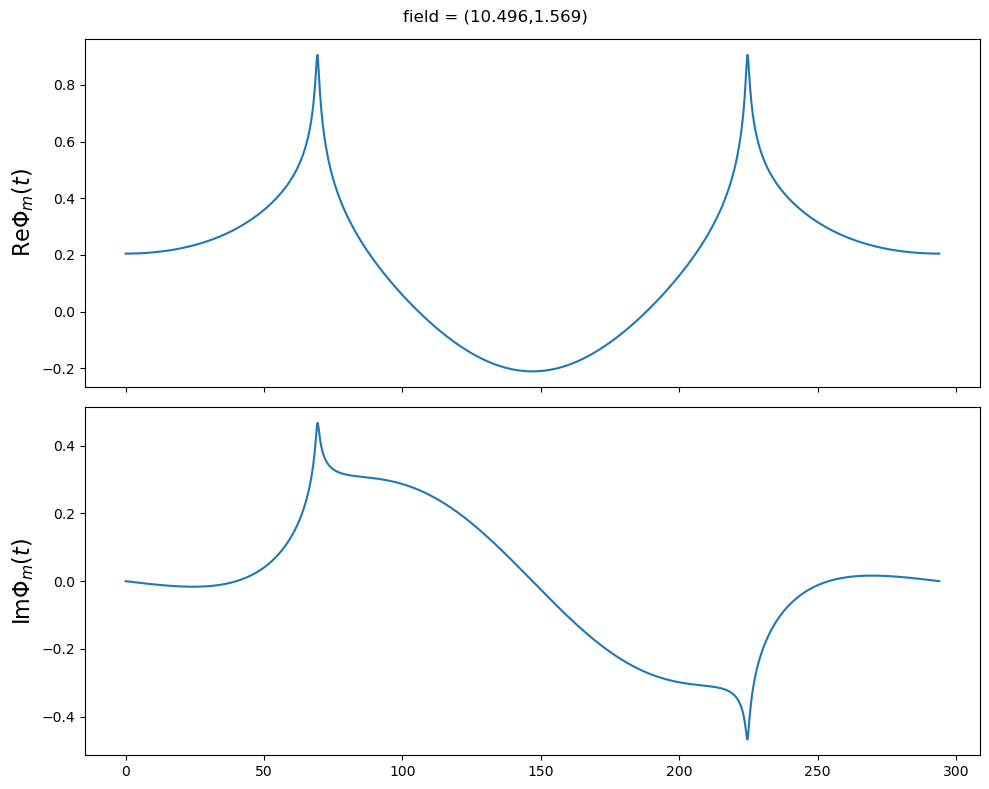

In [27]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(10,8), sharex=True)

data_dict = n_field_timeseries_dict

pt = close
fr, ft = data_dict[pt]['field']

axs[0].plot(data_dict[pt]["time"],data_dict[pt]["data"].real)
axs[0].set_ylabel(r'Re$\Phi_m(t)$',fontsize=16)
axs[1].plot(data_dict[pt]["time"],data_dict[pt]["data"].imag)
axs[1].set_ylabel(r'Im$\Phi_m(t)$',fontsize=16)

plt.suptitle(f"field = ({fr:0.3f},{ft:0.3f})")
plt.tight_layout()
plt.show()

## n-mode source

In [28]:
n_source_data_slices, n_source_timeseries_dict = data_loader("../data/n_source_re.dat","../data/n_source_im.dat",n_radial, n_theta)

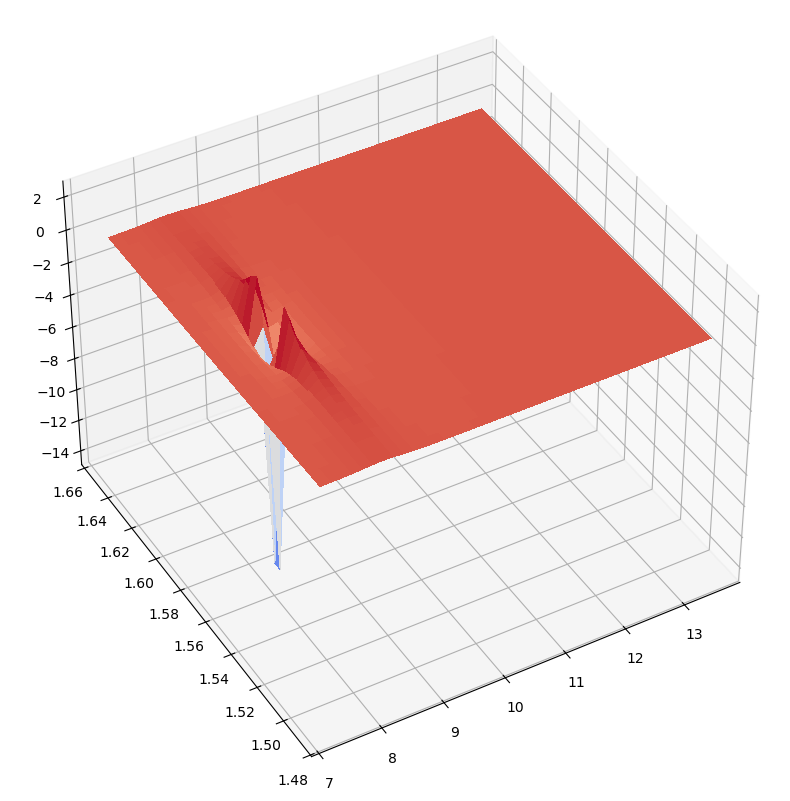

In [29]:
X, Y = np.meshgrid(r_vals, th_vals)
dat = np.array(n_source_data_slices[0][1])

fig, ax = plt.subplots(figsize=(10,10), subplot_kw={"projection":"3d"})
ax.view_init(elev=40, azim=-120, roll=0)

ax.plot_surface(X, Y, np.real(dat), cmap=cm.coolwarm, linewidth=0, antialiased=False)
plt.show()

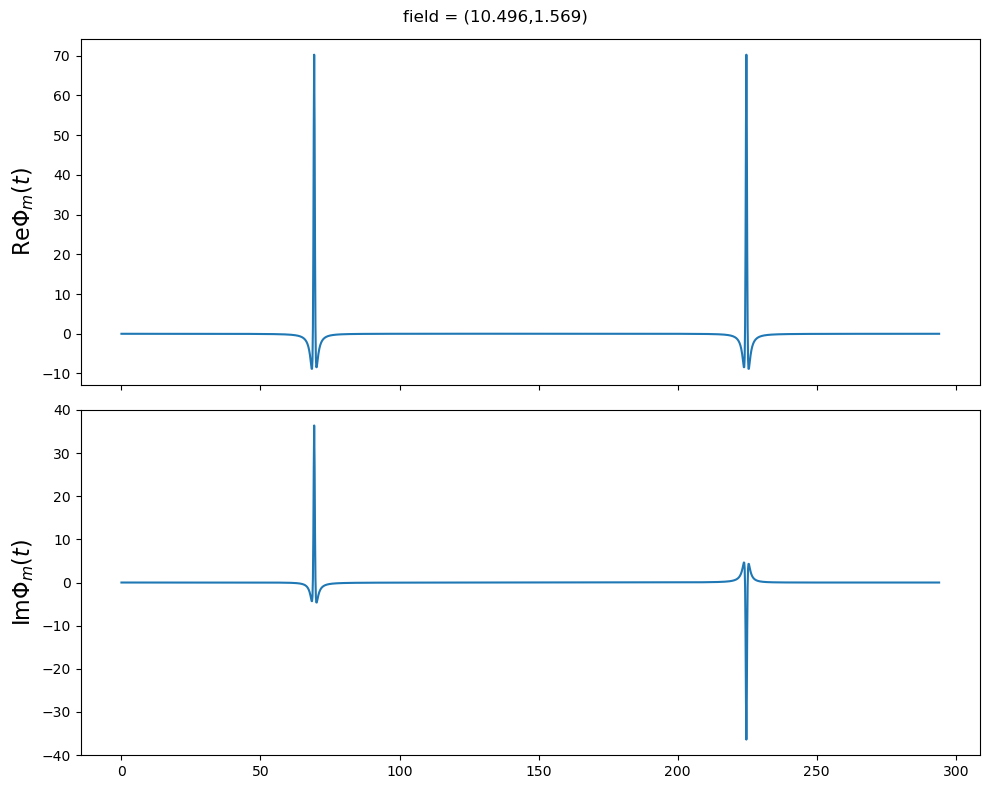

In [30]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(10,8), sharex=True)

data_dict = n_source_timeseries_dict

pt = close
fr, ft = data_dict[pt]['field']

axs[0].plot(data_dict[pt]["time"],data_dict[pt]["data"].real)
axs[0].set_ylabel(r'Re$\Phi_m(t)$',fontsize=16)
axs[1].plot(data_dict[pt]["time"],data_dict[pt]["data"].imag)
axs[1].set_ylabel(r'Im$\Phi_m(t)$',fontsize=16)

plt.suptitle(f"field = ({fr:0.3f},{ft:0.3f})")
plt.tight_layout()
plt.show()

# n-mode derivatives

## dr

In [11]:
n_dr_field_data_slices, n_dr_field_timeseries_dict = data_loader("../data/n_puncture_dr_re.dat","../data/n_puncture_dr_im.dat",n_radial, n_theta)

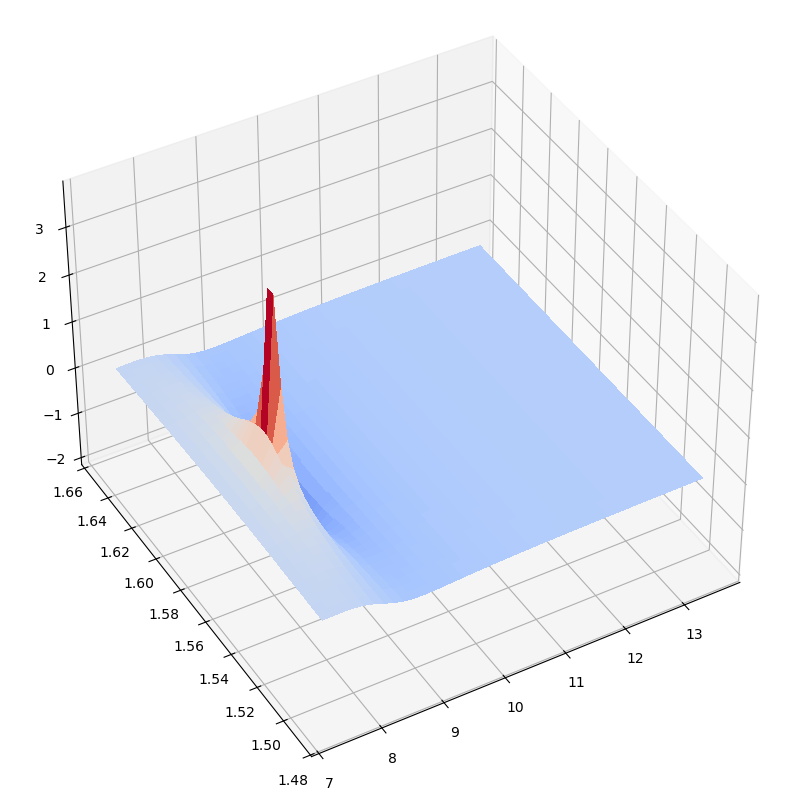

In [12]:
X, Y = np.meshgrid(r_vals, th_vals)
dat = np.array(n_dr_field_data_slices[0][1])

fig, ax = plt.subplots(figsize=(10,10), subplot_kw={"projection":"3d"})
ax.view_init(elev=40, azim=-120, roll=0)

ax.plot_surface(X, Y, np.real(dat), cmap=cm.coolwarm, linewidth=0, antialiased=False)
plt.show()

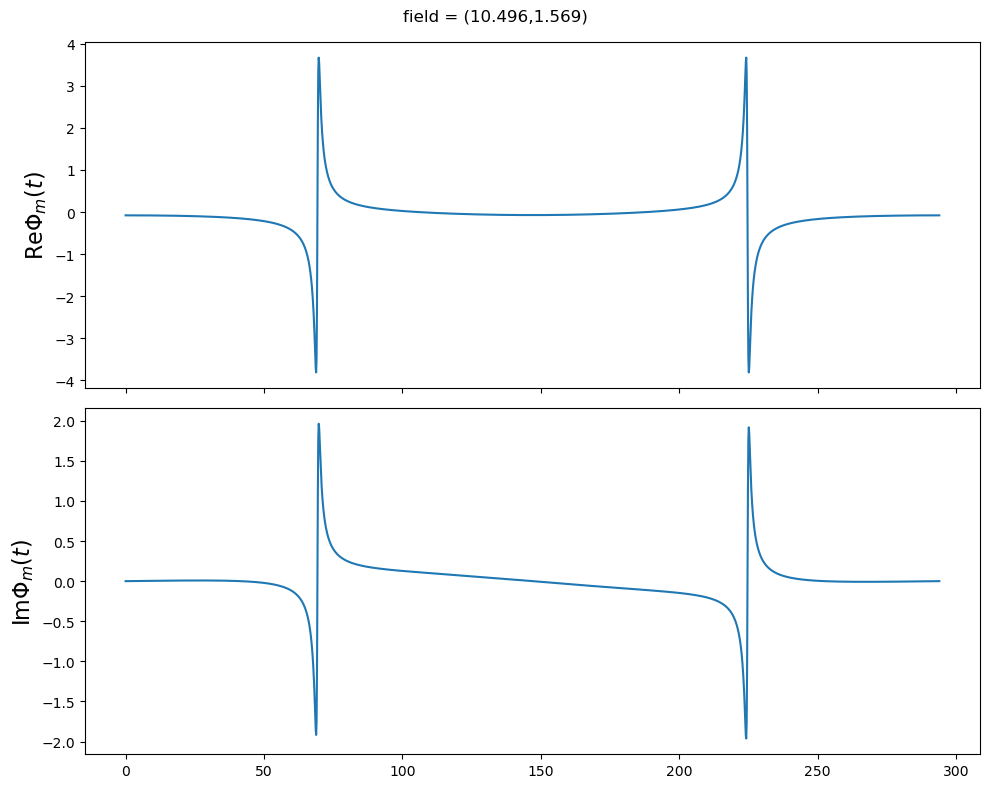

In [13]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(10,8), sharex=True)

data_dict = n_dr_field_timeseries_dict

pt = close
fr, ft = data_dict[pt]['field']

axs[0].plot(data_dict[pt]["time"],data_dict[pt]["data"].real)
axs[0].set_ylabel(r'Re$\Phi_m(t)$',fontsize=16)
axs[1].plot(data_dict[pt]["time"],data_dict[pt]["data"].imag)
axs[1].set_ylabel(r'Im$\Phi_m(t)$',fontsize=16)

plt.suptitle(f"field = ({fr:0.3f},{ft:0.3f})")
plt.tight_layout()
plt.show()

In [14]:
t_test, field_test = n_dr_field_timeseries_dict[pt]["time"], n_dr_field_timeseries_dict[pt]["data"].real
field_int = IUS(t_test, field_test)

(224.0, 226.0)

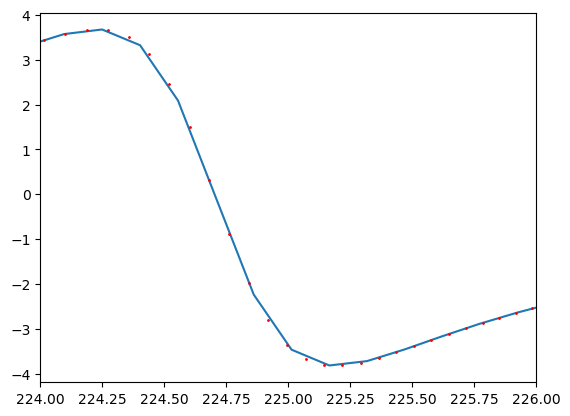

In [15]:
plt.plot(t_test, field_test)
# plt.scatter(t_test,field_test)
# plt.plot(t_test, field_int(t_test))
plt.scatter(t_list, field_int(t_list),s=1,c='r',zorder=5)
# plt.ylim(0.8,1)
plt.xlim(224,226)

(150.0, 152.0)

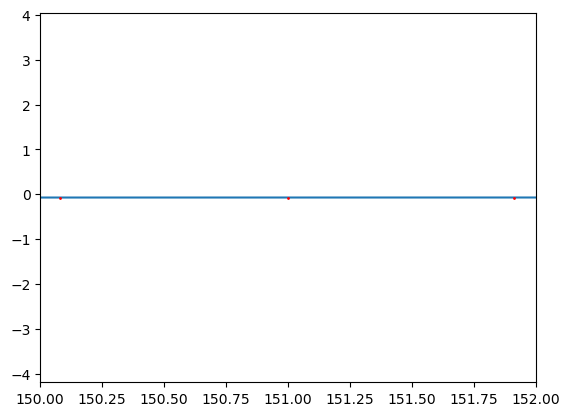

In [16]:
plt.plot(t_test, field_test)
# plt.scatter(t_test,field_test)
# plt.plot(t_test, field_int(t_test))
plt.scatter(t_list, field_int(t_list),s=1,c='r',zorder=5)
# plt.ylim(-0.2,-0.16)
plt.xlim(150,152)

## dtheta

In [66]:
n_dth_field_data_slices, n_dth_field_timeseries_dict = data_loader("../data/n_puncture_dth_re.dat","../data/n_puncture_dth_im.dat",n_radial, n_theta)

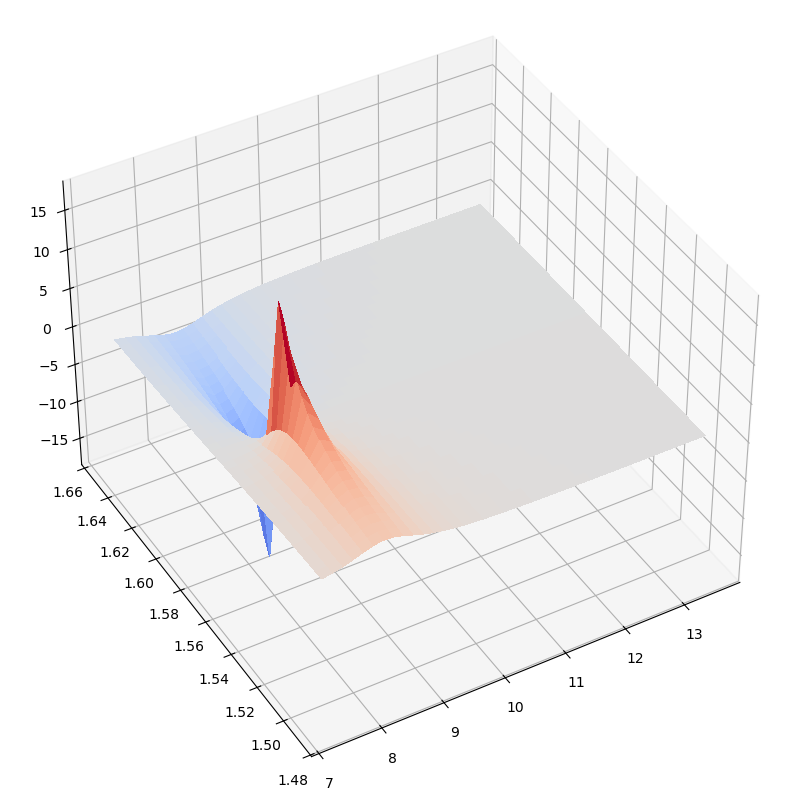

In [67]:
X, Y = np.meshgrid(r_vals, th_vals)
dat = np.array(n_dth_field_data_slices[0][1])

fig, ax = plt.subplots(figsize=(10,10), subplot_kw={"projection":"3d"})
ax.view_init(elev=40, azim=-120, roll=0)

ax.plot_surface(X, Y, np.real(dat), cmap=cm.coolwarm, linewidth=0, antialiased=False)
plt.show()

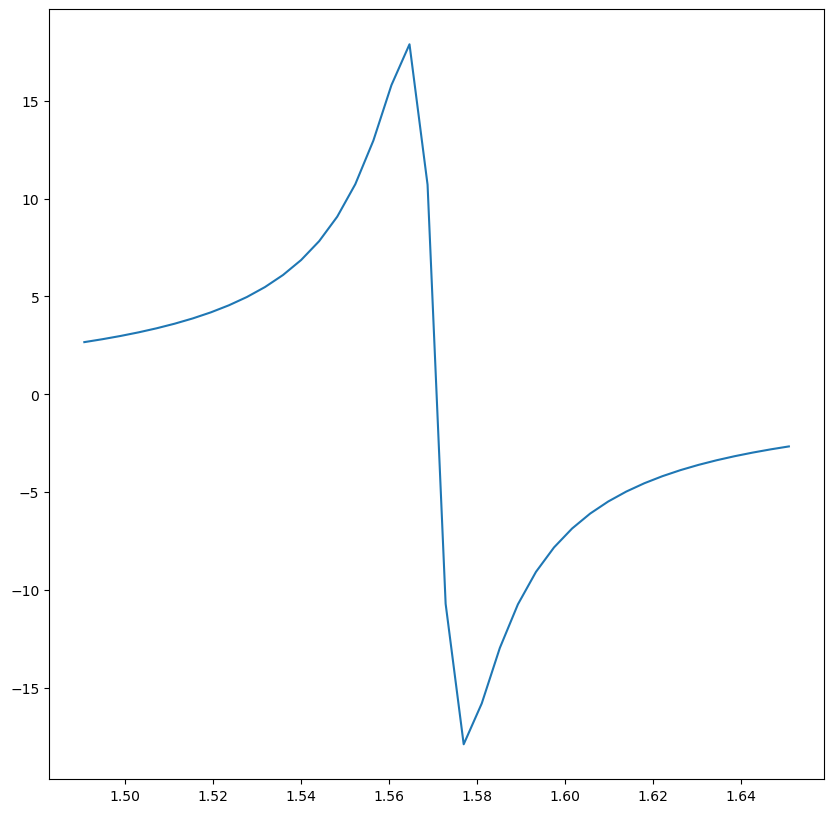

In [68]:
dat = np.array(n_dth_field_data_slices[1][1][:,6])

fig = plt.figure(figsize=(10,10))

plt.plot(th_vals, dat.real)
plt.show()

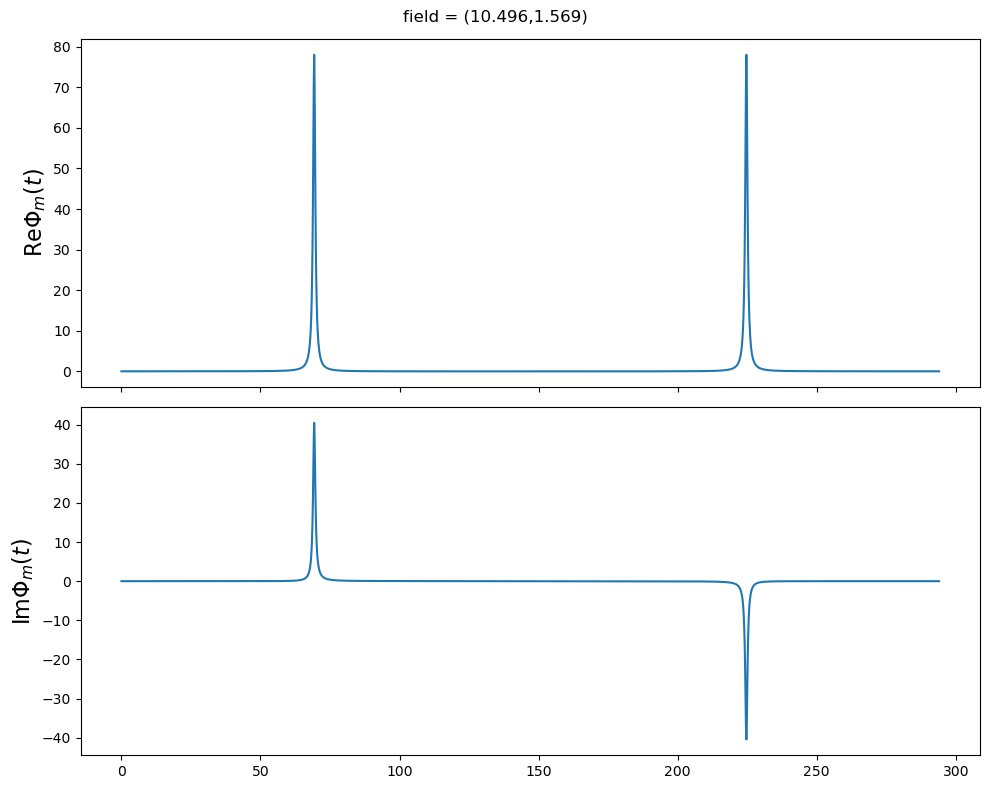

In [69]:
fig, axs = plt.subplots(ncols=1, nrows=2, figsize=(10,8), sharex=True)

data_dict = n_dth_field_timeseries_dict

pt = close
fr, ft = data_dict[pt]['field']

axs[0].plot(data_dict[pt]["time"],data_dict[pt]["data"].real)
axs[0].set_ylabel(r'Re$\Phi_m(t)$',fontsize=16)
axs[1].plot(data_dict[pt]["time"],data_dict[pt]["data"].imag)
axs[1].set_ylabel(r'Im$\Phi_m(t)$',fontsize=16)

plt.suptitle(f"field = ({fr:0.3f},{ft:0.3f})")
plt.tight_layout()
plt.show()

In [70]:
t_test, field_test = n_dth_field_timeseries_dict[pt]["time"], n_dth_field_timeseries_dict[pt]["data"].real
field_int = IUS(t_test, field_test)

(224.0, 226.0)

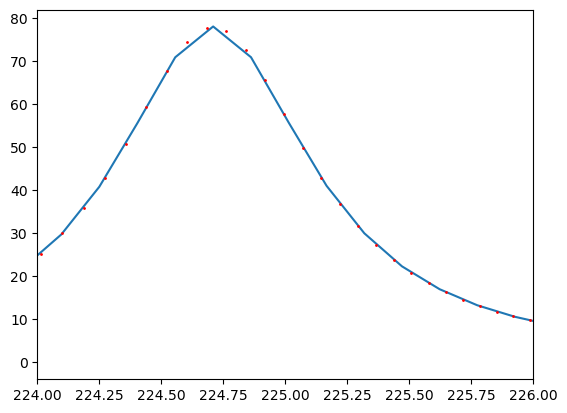

In [71]:
plt.plot(t_test, field_test)
# plt.scatter(t_test,field_test)
# plt.plot(t_test, field_int(t_test))
plt.scatter(t_list, field_int(t_list),s=1,c='r',zorder=5)
# plt.ylim(0.8,1)
plt.xlim(224,226)

(150.0, 152.0)

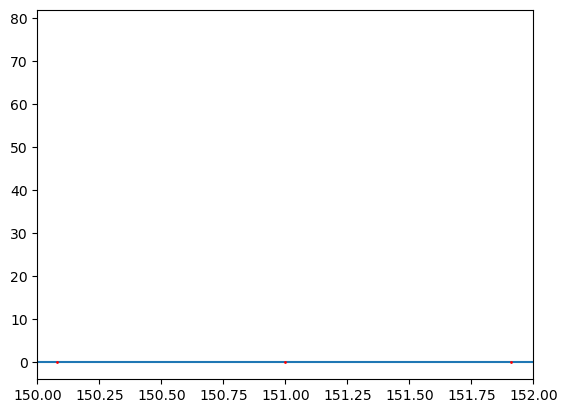

In [72]:
plt.plot(t_test, field_test)
# plt.scatter(t_test,field_test)
# plt.plot(t_test, field_int(t_test))
plt.scatter(t_list, field_int(t_list),s=1,c='r',zorder=5)
# plt.ylim(-0.2,-0.16)
plt.xlim(150,152)